In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [84]:
df = pd.read_csv('data.csv')

### Data Cleaning

In [85]:
# Put all cols in lowercase
df.columns = df.columns.str.lower()

In [86]:
# Find all string cols
strings = list(df.dtypes[df.dtypes == 'str'].index)

In [87]:
# Put all string cols in lowercase and removing all spaces
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

### Data Exploration

In [88]:
# Shows informations about the data in each columns
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine fuel type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine hp
[335. 300. 230. 320. 172.]
356

engine cylinders
[ 6.  4.  5.  8. 12.]
9

transmission type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number of doors
[ 2.  4.  3. nan]
3

market category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

<Axes: xlabel='msrp', ylabel='Count'>

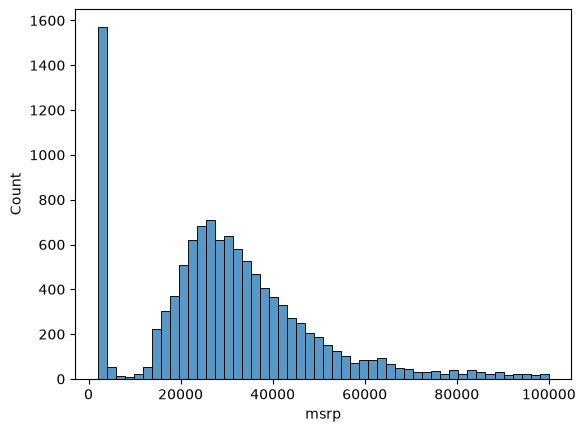

In [89]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50)
# This is a long tail distribution : most of the data is concentrated at the same place and then get thinner as it spreads out to the right. It's pretty common for price data

In [90]:
# While the long tail is something normal, it usually confuse the model, so we need to remove the long tail and the trick is to apply the logarithm to the price
# The logarithm compresses large values. But there's one problem with a plain logarithm : it doesn't exists for zero. If there's a 0, numpy will complains. Even if our data shows that we don't have zeros in it, it's common to add a 1 to all values. Numpy has the exact function to do so log1p.
price_logs = np.log1p(df.msrp)

<Axes: xlabel='msrp', ylabel='Count'>

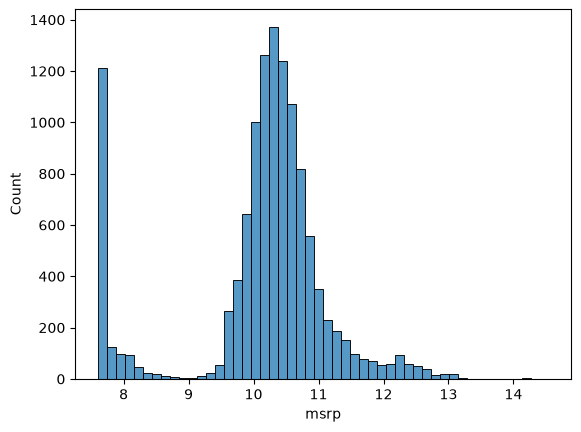

In [91]:
sns.histplot(price_logs, bins=50)
# As we can see, the data is now more evenly distributed : it's called a bell curve (a clear center of the distribution that goes down on both the left and the right side) -> This is a normal distribution (While still ignoring the big peak of cars at 1000)
# This is ideal for models, they tends to do better when the target variable looks like a normal distribution.

In [92]:
# We need to keep in mind the fact that some of the data is null. We will have to do something about it at one point.
df.isnull().sum()

make                    0
model                   0
year                    0
engine fuel type        3
engine hp              69
engine cylinders       30
transmission type       0
driven_wheels           0
number of doors         6
market category      3742
vehicle size            0
vehicle style           0
highway mpg             0
city mpg                0
popularity              0
msrp                    0
dtype: int64

### Validation framework

In [93]:
# Now we need to split our data in three : train, validation and test. We will do a 60/20/20, and so we need to calculate how many records represents the 20%
n = len(df)

n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - n_val - n_test
print(n, n_train, n_val, n_test)

11914 7150 2382 2382


In [94]:
# We could do a simple split like below. But without shuffling the data, we might end up run with the same make inside the same validation set while missing in the test set. We need to shuffle it first. And to make sure we have the same random index we add a seed to it

np.random.seed(2)
idx = np.arange(n)
np.random.shuffle(idx)

df_val = df.iloc[idx[:n_val]]
df_test = df.iloc[idx[n_val:n_val+n_test]]
df_train = df.iloc[idx[n_val+n_test:]]

# With a 2 as our seed, the first record of the train set should be a Chevrolet. (Spoiler : it's not, because we don't have the same numpy version as the course)
df_train.head(1)

,make,model,year,engine fuel type,engine hp,engine cylinders,transmission type,driven_wheels,number of doors,market category,vehicle size,vehicle style,highway mpg,city mpg,popularity,msrp
8597,kia,rondo,2008,regular_unleaded,162.0,4.0,automatic,front_wheel_drive,4.0,NaN,compact,wagon,26,19,1720,16395


In [95]:
# To make, let's check the length
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [96]:
# We need to reset the index of the dataset, because we don't really need to know the original index order
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [97]:
#The dataframes will be used to build our matrix X, the target y comes from the msrp column. We need to apply the log1p to it, and fetch it with values to get a numpy array
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

# We then remove the column for our dataset, we don't want to use the price column to predict prices, it would make the results perfect when we're not trying to do this.
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

### Linear Regression

Regression means predicting numbers. We represents it with this formula
```
g(X) = y
```
Where g is our model, X our matrix and y our target (here the price) But before changing the whole dataset to a matrix, we do it for one row only
```
g(Xi) = yi
```

In [98]:
# In the course, they take the index 10 of the training data. they have a Rolls-Royce, which we probably won't have
df_train.iloc[10]

make                        chevrolet
model                 trailblazer_ext
year                             2004
engine fuel type     regular_unleaded
engine hp                       275.0
engine cylinders                  6.0
transmission type           automatic
driven_wheels        rear_wheel_drive
number of doors                   4.0
market category                   NaN
vehicle size                    large
vehicle style                 4dr_suv
highway mpg                        18
city mpg                           13
popularity                       1385
Name: 10, dtype: object

In [99]:
# The first array is built from the values of the following columns : engine hp, city mgp, popularity
xi = [275, 13, 1385]
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [100]:
# For now, we will create a function that will compute a prediction for us
def linear_regression(xi):
    n = len(xi)
    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]

    return pred

In [101]:
# This is not the price in dollar, it's the logarithm of the price
print(linear_regression(xi))

# To undo the logarithm of the price, we have to make an exponent. Giving us a price of 545 795 dollars
np.expm1(linear_regression(xi)).round()

13.209999999999999


np.float64(545795.0)

### Linear Regression vector form

In [102]:
# We can update the function to be more simple
def dot(xi, w):
    n = len(xi)
    res = 0.0
    for j in range(n):
        res = res + xi[j] * w[j]
    return res

def updated_linear_regression(xi):
    xi = [1] + xi
    return w0 + dot(xi, w)

In [104]:
# At the end of the day we are going to muliply our weights vector directly to our matrix of car data

### Linear Regression Training

One point to remember we can't calculate the weigh without a square matrix. So we use the Gram matrix.

To obtain weight, we need to calculate the weight vector, for this we can use the function below :

In [105]:
def train_linear_regression(x,y):
    ones = np.ones(x.shape[0])
    x = np.column_stack([ones, x])

    XTX = x.T.dot(x)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(x.T).dot(y)

    return w_full[0], w_full[1:]

### Baseline model for car price prediction

We can now finally calculate the prices of our data, our first model will be what we call a baseline model. It will only hold numerical values, and will our starting point for improvement later on.

In [106]:
df_train.columns

Index(['make', 'model', 'year', 'engine fuel type', 'engine hp',
       'engine cylinders', 'transmission type', 'driven_wheels',
       'number of doors', 'market category', 'vehicle size', 'vehicle style',
       'highway mpg', 'city mpg', 'popularity'],
      dtype='str')

In [117]:
# Linear regression with the way we implemented it, only works with numerical columns : engine_hp, engine_cylinders, highway_mgp, city_mgp, popularity. So we take our columns and create a new base
base = ['engine hp', 'engine cylinders', 'highway mpg', 'city mpg', 'popularity']

# We then apply this subset of columns to our dataframe
X_train = df_train[base].values

In [118]:
# First, we need to make we don't have any nan values as the empty values will make our calculation wrong.
df_train[base].isnull().sum()

engine hp           0
engine cylinders    0
highway mpg         0
city mpg            0
popularity          0
dtype: int64

In [119]:
# The easiest way to dell with it, is to fill it with zeroes. We could do it with the mean instead as it is more reasonable, but from a practical point of view, zeroes keeps the process simple.
X_train = df_train[base].fillna(0).values

In [120]:
# Let's tests our weight calculation :
w0, w = train_linear_regression(X_train, y_train)

In [122]:
# Our weight comes out at 7,96
print(w0)

7.9635564750962855


In [123]:
# Now we can apply the trained model to the training data by using matix multiplication :
y_pred = X_train.dot(w) + w0

<Axes: ylabel='Count'>

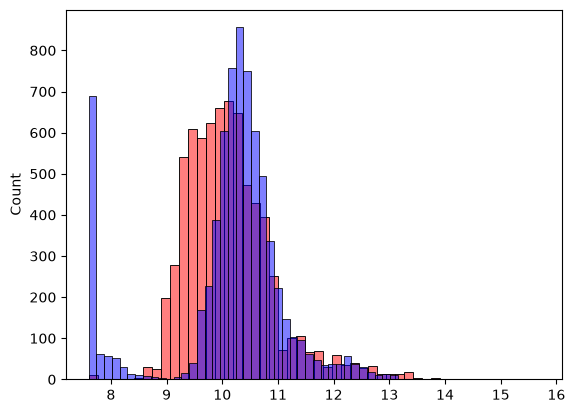

In [124]:
# Now we can see how well our model predicted prices by using seaborn
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

In [125]:
#By looking at the chart above we can see that our model isn't correct on its prediction as the peak of the date sits a bit to the left. We might suspect that the model isn't correct because it's underpredicting the prices. But we can't really tell for sure.

### RMSE (Root mean squared error)